# Explore here

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

archivo = "https://breathecode.herokuapp.com/asset/internal-link?id=929&path=medical_insurance_cost.csv"

df = pd.read_csv(archivo)

print("--- Primeras 5 filas ---")
print(df.head())

print("\n--- Tamaño del dataset (Filas, Columnas) ---")
print(df.shape)

print("\n--- Tipos de datos y nulos ---")
df.info()

--- Primeras 5 filas ---
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

--- Tamaño del dataset (Filas, Columnas) ---
(1338, 7)

--- Tipos de datos y nulos ---
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 K

--- Resumen Estadístico ---


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010



--- Número de filas duplicadas: 1 ---
¡Filas duplicadas eliminadas exitosamente!


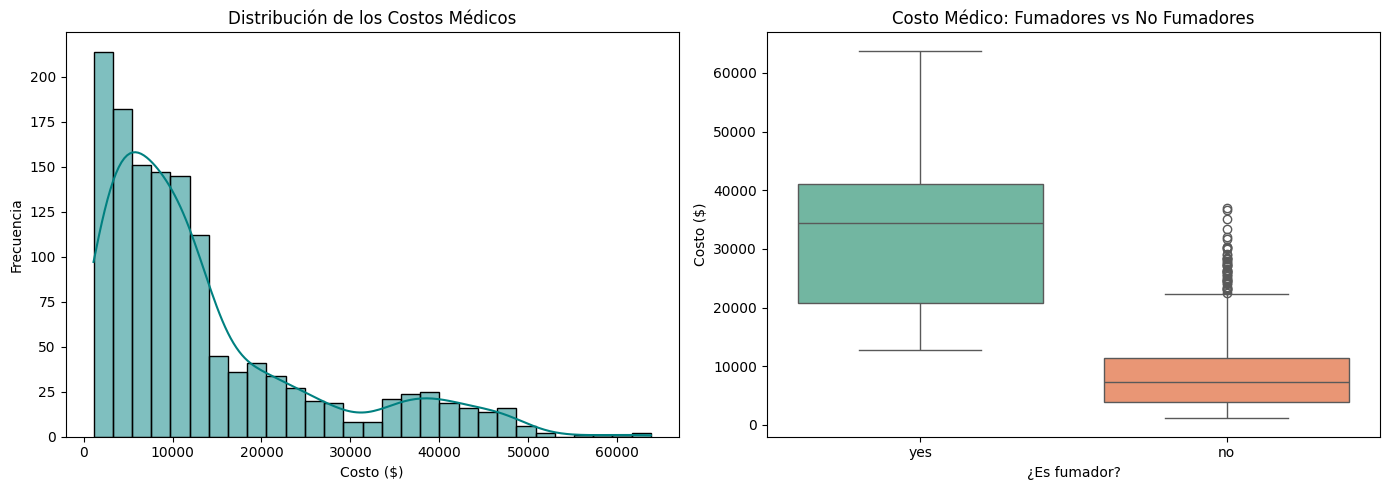

In [6]:
print("--- Resumen Estadístico ---")
display(df.describe()) 

duplicados = df.duplicated().sum()
print(f"\n--- Número de filas duplicadas: {duplicados} ---")

if duplicados > 0:
    df = df.drop_duplicates()
    print("¡Filas duplicadas eliminadas exitosamente!")

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['charges'], kde=True, color='teal')
plt.title('Distribución de los Costos Médicos')
plt.xlabel('Costo ($)')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.boxplot(x='smoker', y='charges', data=df, palette='Set2', hue='smoker', legend=False)
plt.title('Costo Médico: Fumadores vs No Fumadores')
plt.xlabel('¿Es fumador?')
plt.ylabel('Costo ($)')

plt.tight_layout()
plt.show()

--- Dataset Procesado (Solo Números) ---


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


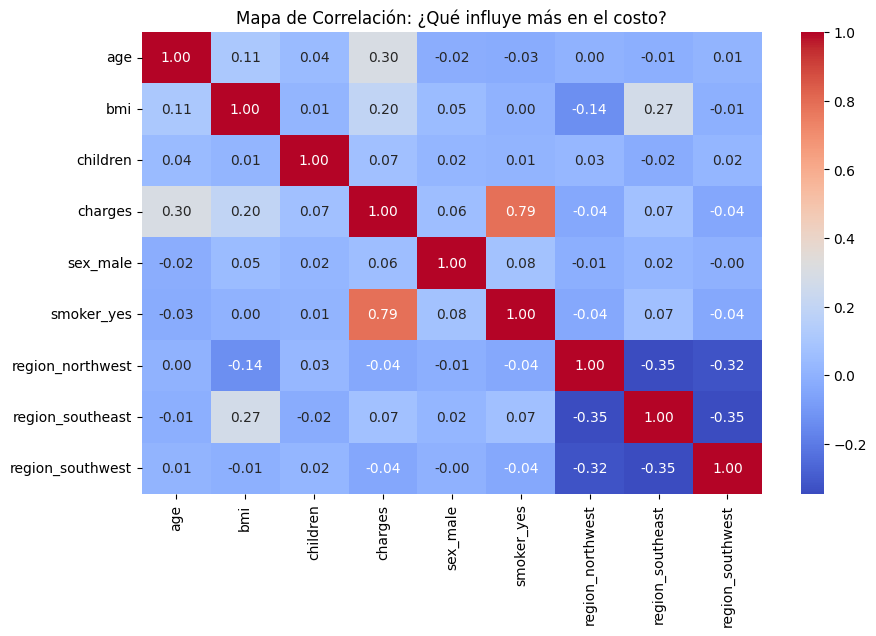

In [7]:
df_procesado = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

print("--- Dataset Procesado (Solo Números) ---")
display(df_procesado.head())

plt.figure(figsize=(10, 6))
sns.heatmap(df_procesado.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Correlación: ¿Qué influye más en el costo?')
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = df_procesado.drop('charges', axis=1)

y = df_procesado['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Datos para entrenar: {X_train.shape[0]} filas")
print(f"Datos para probar: {X_test.shape[0]} filas")

modelo_regresion = LinearRegression()

modelo_regresion.fit(X_train, y_train)
print("\n¡El modelo ha sido entrenado con éxito!")

predicciones = modelo_regresion.predict(X_test)

error_cuadratico_medio = mean_squared_error(y_test, predicciones)
r_cuadrado = r2_score(y_test, predicciones)

print("\n--- Resultados de la Evaluación ---")

print(f"Coeficiente de Determinación (R²): {r_cuadrado:.4f}")

Datos para entrenar: 1069 filas
Datos para probar: 268 filas

¡El modelo ha sido entrenado con éxito!

--- Resultados de la Evaluación ---
Coeficiente de Determinación (R²): 0.8069


--- Evaluación Completa del Modelo ---
Error Cuadrático Medio (MSE): 35478020.68
Raíz del Error Cuadrático Medio (RMSE): 5956.34
Error Absoluto Medio (MAE): 4177.05
Coeficiente de Determinación (R²): 0.8069


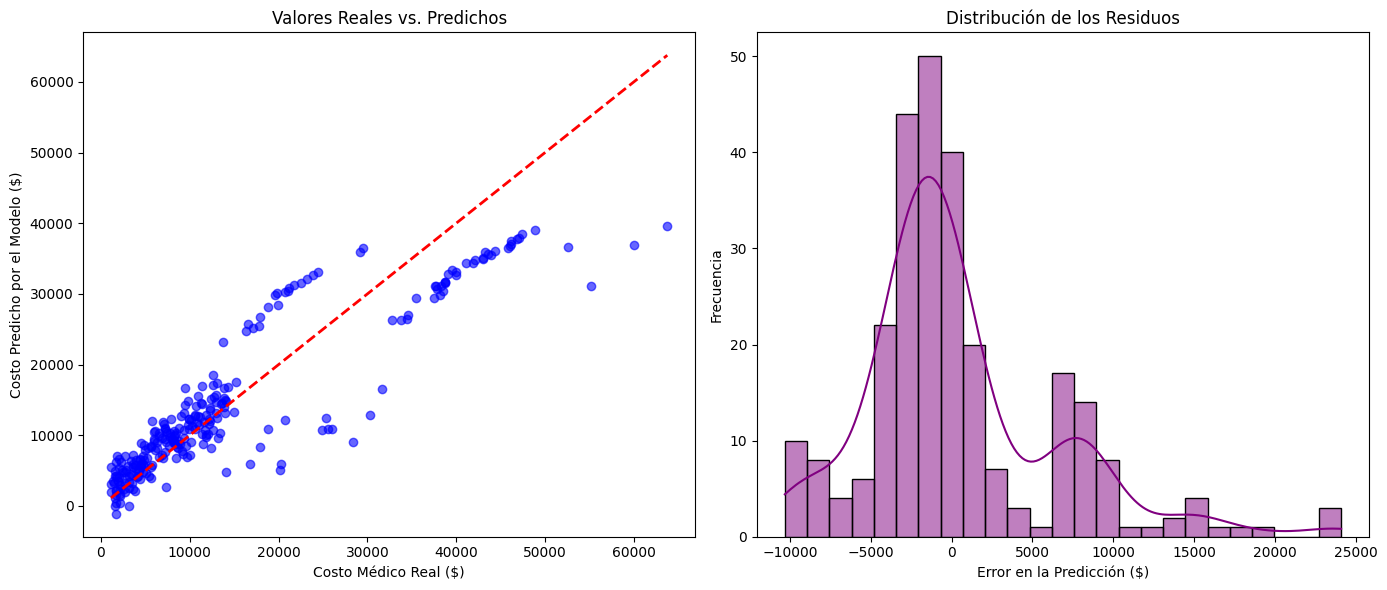

In [9]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

mse = mean_squared_error(y_test, predicciones)
rmse = np.sqrt(mse) 
mae = mean_absolute_error(y_test, predicciones)
r2 = r2_score(y_test, predicciones)

print("--- Evaluación Completa del Modelo ---")
print(f"Error Cuadrático Medio (MSE): {mse:.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f}")
print(f"Error Absoluto Medio (MAE): {mae:.2f}")
print(f"Coeficiente de Determinación (R²): {r2:.4f}")

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(y_test, predicciones, alpha=0.6, color='blue')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Costo Médico Real ($)')
plt.ylabel('Costo Predicho por el Modelo ($)')
plt.title('Valores Reales vs. Predichos')

plt.subplot(1, 2, 2)

residuos = y_test - predicciones 
sns.histplot(residuos, kde=True, color='purple')
plt.xlabel('Error en la Predicción ($)')
plt.ylabel('Frecuencia')
plt.title('Distribución de los Residuos')

plt.tight_layout()
plt.show()